<a href="https://colab.research.google.com/github/Faseeh56/Customer_churn_prediction_ANN/blob/main/Customer_churn_prediction_DL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
# load dataset
df = pd.read_csv("/content/Telco-Customer-Churn.csv")

## **`Initial-Inspection`**

In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.shape

(7043, 21)

In [ ]:
df.columns.tolist()

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

In [ ]:
df.head(3)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## **`Pre processing of data`**

We found that a column `TotalCharges` has numerical values like floating number but the datatype shown is object which is unusual so lets have a look:

In [ ]:
# findding the entity where TotalCharges column have ' '
df[df['TotalCharges'] == " "]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


This is the bug causing the change of datatype of numerical data. to handel such problems firstly we will change the data to numeric, and pass the column name which we want to be numeric and a parameter `error = 'coerce'` so that any value which is other than numeric like string or blank spaces will be converted into NaN(Not a number)

In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


We can see here now there is 11 NaN values which were blank spaces causing the column to behave as object data type.

In [ ]:
df[df['TotalCharges'].isnull()][['tenure', 'MonthlyCharges']]

,tenure,MonthlyCharges
488,0,52.55
753,0,20.25
936,0,80.85
1082,0,25.75
1340,0,56.05
3331,0,19.85
3826,0,25.35
4380,0,20.00
5218,0,19.70
6670,0,73.35


In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


Checked wheather the NaN columns have tenure 0 or more beacuse if tenure is greater than 0 it would be another problem with our data which don't make sense and we have to fill those values with median or mode, but in our case the tenure is 0 thus we can replace the NaN values with 0

In [ ]:
df['TotalCharges'].fillna(0, inplace=True)

/tmp/ipykernel_4348/171940771.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(0, inplace=True)


In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Now we have a clean an making sense data every numerical and categorical data is inspected we can now proceed to next phase.


In [ ]:
# drop ID column
df.drop('customerID', axis=1, inplace=True)

In [ ]:
# checking wheather a column is binary categorical(0,1) or multi categrical(3 or more)
df.nunique()

,0
gender,2
SeniorCitizen,2
Partner,2
Dependents,2
tenure,73
PhoneService,2
MultipleLines,3
InternetService,3
OnlineSecurity,3
OnlineBackup,3


In [ ]:
df['OnlineSecurity'].unique()

array(['No', 'Yes', 'No internet service'], dtype=object)

In [ ]:
df['MultipleLines'].unique()

array(['No phone service', 'No', 'Yes'], dtype=object)

In [ ]:
cols_with_no_internet_service = []
for col in df.columns:
    if df[col].dtype == 'object':
        if 'No internet service' in df[col].unique():
            cols_with_no_internet_service.append(col)

print("Columns with 'No internet service' value:", cols_with_no_internet_service)

Columns with 'No internet service' value: ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']


In [ ]:
print("Other unique values in identified columns (excluding 'No internet service'):")
for col in cols_with_no_internet_service:
    other_unique_values = [val for val in df[col].unique() if val != 'No internet service']
    print(f"{col}: {other_unique_values}")

Other unique values in identified columns (excluding 'No internet service'):
OnlineSecurity: ['No', 'Yes']
OnlineBackup: ['Yes', 'No']
DeviceProtection: ['No', 'Yes']
TechSupport: ['No', 'Yes']
StreamingTV: ['No', 'Yes']
StreamingMovies: ['No', 'Yes']


### Replacing 'No internet service' with 'No'

In [ ]:
for col in cols_with_no_internet_service:
    df[col] = df[col].replace('No internet service', 'No')

print("Values replaced successfully in the following columns:", cols_with_no_internet_service)

Values replaced successfully in the following columns: ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']


Let's verify the changes by checking the unique values in one of these columns again, for example `OnlineSecurity`.

In [ ]:
df['OnlineSecurity'].unique()

array(['No', 'Yes'], dtype=object)

we got some categorical columns which have an extra value for 'No internet service' which is already there as 'No' so we don't need it, so we replaced the 'No internet service' value with 'No' in every column.

In [ ]:
df.nunique()

,0
gender,2
SeniorCitizen,2
Partner,2
Dependents,2
tenure,73
PhoneService,2
MultipleLines,3
InternetService,3
OnlineSecurity,2
OnlineBackup,2


In [ ]:
df['MultipleLines'].unique()

array(['No phone service', 'No', 'Yes'], dtype=object)

In [ ]:
df['MultipleLines'] = df['MultipleLines'].replace('No phone service', 'No')

df['MultipleLines'].unique()

array(['No', 'Yes'], dtype=object)

## **`label encoding`**

In [ ]:
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})
df['Churn'].unique()

array([0, 1])

In [ ]:
print(df.info())
print(df.nunique())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [ ]:
Binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService','MultipleLines','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies', 'PaperlessBilling']
multi_cols = ['Contract', 'PaymentMethod', 'InternetService']
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

In [ ]:
for col in Binary_cols:
    print(col, df[col].unique())

gender ['Female' 'Male']
Partner ['Yes' 'No']
Dependents ['No' 'Yes']
PhoneService ['No' 'Yes']
MultipleLines ['No' 'Yes']
OnlineSecurity ['No' 'Yes']
OnlineBackup ['Yes' 'No']
DeviceProtection ['No' 'Yes']
TechSupport ['No' 'Yes']
StreamingTV ['No' 'Yes']
StreamingMovies ['No' 'Yes']
PaperlessBilling ['Yes' 'No']


In [ ]:
df['gender'] = df['gender'].map({'Male':1, 'Female':0})
df['gender'].unique()


array([0, 1])

In [ ]:
Binary_cols = ['Partner', 'Dependents', 'PhoneService','MultipleLines','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies', 'PaperlessBilling']

In [ ]:
for col in Binary_cols:
    df[col] = df[col].map({'Yes':1, 'No':0})


In [ ]:
for col in Binary_cols:
    print(col, df[col].unique())

Partner [1 0]
Dependents [0 1]
PhoneService [0 1]
MultipleLines [0 1]
OnlineSecurity [0 1]
OnlineBackup [1 0]
DeviceProtection [0 1]
TechSupport [0 1]
StreamingTV [0 1]
StreamingMovies [0 1]
PaperlessBilling [1 0]


In [ ]:
df = pd.get_dummies(df, columns=multi_cols, drop_first=True)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

In [ ]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,MonthlyCharges,TotalCharges,Churn,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,InternetService_Fiber optic,InternetService_No
0,0,0,1,0,-1.277445,0,0,0,1,0,...,-1.160323,-0.992611,0,False,False,False,True,False,False,False
1,1,0,0,0,0.066327,1,0,1,0,1,...,-0.259629,-0.172165,0,True,False,False,False,True,False,False
2,1,0,0,0,-1.236724,1,0,1,1,0,...,-0.362660,-0.958066,1,False,False,False,False,True,False,False
3,1,0,0,0,0.514251,0,0,1,0,1,...,-0.746535,-0.193672,0,True,False,False,False,False,False,False
4,0,0,0,0,-1.236724,1,0,0,0,0,...,0.197365,-0.938874,1,False,False,False,True,False,True,False


In [ ]:
df.shape

(7043, 24)

In [ ]:
boolean_cols = df.select_dtypes(include='bool').columns

if not boolean_cols.empty:
    for col in boolean_cols:
        df[col] = df[col].astype(int)
    print("Boolean columns converted to integers.")
else:
    print("No boolean columns found in the DataFrame.")

Boolean columns converted to integers.


In [ ]:
display(df.head())

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,MonthlyCharges,TotalCharges,Churn,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,InternetService_Fiber optic,InternetService_No
0,0,0,1,0,-1.277445,0,0,0,1,0,...,-1.160323,-0.992611,0,0,0,0,1,0,0,0
1,1,0,0,0,0.066327,1,0,1,0,1,...,-0.259629,-0.172165,0,1,0,0,0,1,0,0
2,1,0,0,0,-1.236724,1,0,1,1,0,...,-0.362660,-0.958066,1,0,0,0,0,1,0,0
3,1,0,0,0,0.514251,0,0,1,0,1,...,-0.746535,-0.193672,0,1,0,0,0,0,0,0
4,0,0,0,0,-1.236724,1,0,0,0,0,...,0.197365,-0.938874,1,0,0,0,1,0,1,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 24 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7043 non-null   int64  
 1   SeniorCitizen                          7043 non-null   int64  
 2   Partner                                7043 non-null   int64  
 3   Dependents                             7043 non-null   int64  
 4   tenure                                 7043 non-null   float64
 5   PhoneService                           7043 non-null   int64  
 6   MultipleLines                          7043 non-null   int64  
 7   OnlineSecurity                         7043 non-null   int64  
 8   OnlineBackup                           7043 non-null   int64  
 9   DeviceProtection                       7043 non-null   int64  
 10  TechSupport                            7043 non-null   int64  
 11  Stre

In [ ]:
df.shape

(7043, 24)

In [ ]:
# Save the cleaned DataFrame to a CSV file
df.to_csv('cleaned_telco_customer_churn_dataset.csv', index=False)
print("Cleaned data saved to 'cleaned_telco_customer_churn_dataset.csv'")

Cleaned data saved to 'cleaned_telco_customer_churn_dataset.csv'


In [ ]:
df = pd.read_csv("/content/cleaned_telco_customer_churn_dataset.csv")

In [ ]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,MonthlyCharges,TotalCharges,Churn,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,InternetService_Fiber optic,InternetService_No
0,0,0,1,0,-1.277445,0,0,0,1,0,...,-1.160323,-0.992611,0,0,0,0,1,0,0,0
1,1,0,0,0,0.066327,1,0,1,0,1,...,-0.259629,-0.172165,0,1,0,0,0,1,0,0
2,1,0,0,0,-1.236724,1,0,1,1,0,...,-0.362660,-0.958066,1,0,0,0,0,1,0,0
3,1,0,0,0,0.514251,0,0,1,0,1,...,-0.746535,-0.193672,0,1,0,0,0,0,0,0
4,0,0,0,0,-1.236724,1,0,0,0,0,...,0.197365,-0.938874,1,0,0,0,1,0,1,0


# **`ANN`**

In [ ]:
# 1. Import Libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
# 2. Load Processed Dataset

df = pd.read_csv('/content/cleaned_telco_customer_churn_dataset.csv')

In [ ]:
# 3. Separate Features & Target

X = df.drop('Churn', axis=1)
y = df['Churn']

In [ ]:
# 4. Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# 5. Build ANN Model
model = Sequential()

# Input layer + 1st hidden layer
model.add(Dense(36, activation='relu', input_dim=X.shape[1]))
model.add(BatchNormalization())
model.add(Dropout(0.3))

# 2nd hidden layer
model.add(Dense(16, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.2))


# Output layer (Binary Classification)
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# 6. Compile Model

optimizer = Adam(learning_rate=0.001)

model.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# 7. Callbacks (Prevent Overfitting)
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

In [ ]:
# 8. Train Model

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
177/177 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.6837 - loss: 0.6497 - val_accuracy: 0.7942 - val_loss: 0.4493
Epoch 2/50
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7460 - loss: 0.5164 - val_accuracy: 0.8126 - val_loss: 0.4164
Epoch 3/50
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7748 - loss: 0.4720 - val_accuracy: 0.8112 - val_loss: 0.4070
Epoch 4/50
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7758 - loss: 0.4743 - val_accuracy: 0.8148 - val_loss: 0.4048
Epoch 5/50
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7812 - loss: 0.4575 - val_accuracy: 0.8119 - val_loss: 0.4011
Epoch 6/50
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7836 - loss: 0.4512 - val_accuracy: 0.8162 - val_loss: 0.4013
Epoch 7/50
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7810 - loss: 0.4508 - val_accuracy: 0.8162 - val_loss: 0.3991
Epoch 8/50
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7852 - loss: 0.4450 - val_accuracy: 0

In [ ]:
 # 9. Predictions
y_prob = model.predict(X_test)

# Convert probabilities → 0/1
y_pred = (y_prob > 0.5).astype(int)

45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


In [ ]:
# 10. Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.815471965933286

Confusion Matrix:
 [[941  95]
 [165 208]]

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.91      0.88      1036
           1       0.69      0.56      0.62       373

    accuracy                           0.82      1409
   macro avg       0.77      0.73      0.75      1409
weighted avg       0.81      0.82      0.81      1409



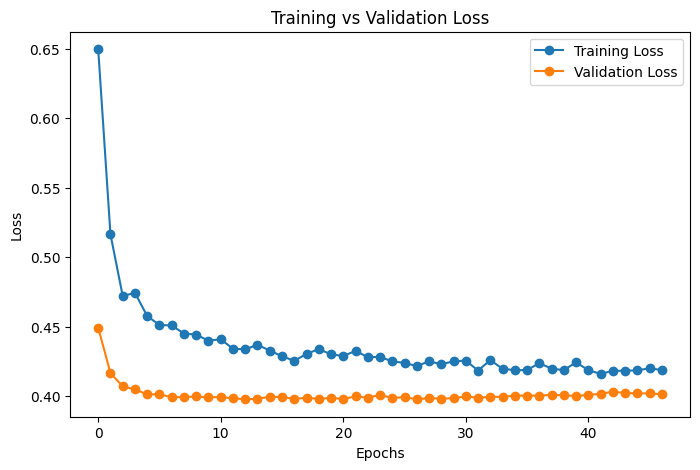

In [ ]:
# Visaulisations
import matplotlib.pyplot as plt

# Plot training & validation loss values
train_loss = history.history['loss']
val_loss = history.history['val_loss']


plt.figure(figsize=(8,5))

plt.plot(train_loss, label='Training Loss', marker='o')
plt.plot(val_loss, label='Validation Loss', marker='o')

plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

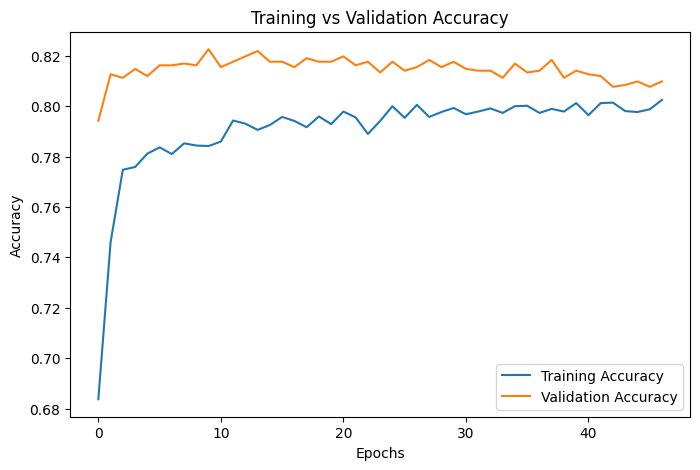

In [ ]:
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

plt.figure(figsize=(8,5))

plt.plot(train_acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')

plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()